# Phase 2: Real Data Preparation & Exploratory Analysis

**Goal:** Transform the three raw Starbucks JSON files into a clean, customer-level dataset with a defensible treatment/outcome definition — while documenting every decision made along the way.

This phase carries the highest risk in the whole project. If treatment or outcome is mislabeled here, every downstream causal estimate is meaningless regardless of how correctly the modeling is done later. Roughly 40-50% of total project time went into this phase for exactly that reason.

**What this notebook covers:**
1. Recon on the three raw files (portfolio, profile, transcript)
2. The offer-overlap discovery — a major finding that changed the treatment definition strategy
3. Building the last-touch attribution logic and the final customer-level table using `src/data_prep.py`
4. Sanity checks on the final processed dataset

In [25]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt

from src.data_prep import (
    load_json_lines,
    build_offer_windows,
    build_viewed_events,
    get_transactions,
    attribute_transactions,
    build_customer_level_table,
    add_covariates,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

RAW_DIR = "../data/raw"

## Step 1: Recon on the raw files

Before building any pipeline logic, we inspect each file to answer one question: *which features can we confidently commit to?*

In [26]:
portfolio_df = load_json_lines(f"{RAW_DIR}/portfolio.json")
profile_df = load_json_lines(f"{RAW_DIR}/profile.json")
transcript_df = load_json_lines(f"{RAW_DIR}/transcript.json")

print(f"Portfolio: {portfolio_df.shape}")
print(f"Profile:   {profile_df.shape}")
print(f"Transcript: {transcript_df.shape}")

Portfolio: (10, 6)
Profile:   (17000, 5)
Transcript: (306534, 4)


### Portfolio: 10 offers, 3 types

We need the discount offer IDs specifically, since our treatment definition filters to discount-vs-no-offer.

In [27]:
display(portfolio_df)

print("\nOffer type counts:")
display(portfolio_df["offer_type"].value_counts())

discount_ids = portfolio_df.loc[portfolio_df["offer_type"] == "discount", "id"].tolist()
print(f"\nDiscount offer IDs: {discount_ids}")

,reward,channels,difficulty,duration,offer_type,id
0,10,"[email, mobile, social]",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,10,"[web, email, mobile, social]",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,0,"[web, email, mobile]",0,4,informational,3f207df678b143eea3cee63160fa8bed
3,5,"[web, email, mobile]",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,5,"[web, email]",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7
5,3,"[web, email, mobile, social]",7,7,discount,2298d6c36e964ae4a3e7e9706d1fb8c2
6,2,"[web, email, mobile, social]",10,10,discount,fafdcd668e3743c1bb461111dcafc2a4
7,0,"[email, mobile, social]",0,3,informational,5a8bc65990b245e5a138643cd4eb9837
8,5,"[web, email, mobile, social]",5,5,bogo,f19421c1d4aa40978ebb69ca19b0e20d
9,2,"[web, email, mobile]",10,7,discount,2906b810c7d4411798c6938adc9daaa5



Offer type counts:


offer_type
bogo             4
discount         4
informational    2
Name: count, dtype: int64


Discount offer IDs: ['0b1e1539f2cc45b7b9fa7c272da2e1d7', '2298d6c36e964ae4a3e7e9706d1fb8c2', 'fafdcd668e3743c1bb461111dcafc2a4', '2906b810c7d4411798c6938adc9daaa5']


### Profile: demographics and a known missing-data pattern

Starbucks uses `age == 118` as a placeholder for missing demographic data. This isn't three independent data-quality issues — age, income, and gender are all missing for the exact same group of customers, likely incomplete signups.

In [28]:
display(profile_df.head())

print("Missing values per column:")
display(profile_df.isna().sum())

placeholder_count = (profile_df["age"] == 118).sum()
print(f"\nCustomers with age == 118 (missing-data placeholder): {placeholder_count}")

,gender,age,id,became_member_on,income
0,None,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0
2,None,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0
4,None,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN


Missing values per column:


gender              2175
age                    0
id                     0
became_member_on       0
income              2175
dtype: int64


Customers with age == 118 (missing-data placeholder): 2175


### Transcript: event log

This is the file that requires the most care. Event counts below, followed by a manual trace of one customer's full history — the first step in verifying that automated treatment/outcome labeling logic will actually behave correctly.

In [29]:
print("Event type counts:")
display(transcript_df["event"].value_counts())

print("\nSample 'value' objects per event type (note the key naming inconsistency):")
for ev in transcript_df["event"].unique():
    sample = transcript_df.loc[transcript_df["event"] == ev, "value"].iloc[0]
    print(f"  {ev}: {sample}")

Event type counts:


event
transaction        138953
offer received      76277
offer viewed        57725
offer completed     33579
Name: count, dtype: int64


Sample 'value' objects per event type (note the key naming inconsistency):
  offer received: {'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'}
  offer viewed: {'offer id': 'f19421c1d4aa40978ebb69ca19b0e20d'}
  transaction: {'amount': 0.8300000000000001}
  offer completed: {'offer_id': '2906b810c7d4411798c6938adc9daaa5', 'reward': 2}


**Important gotcha found here:** `offer received` and `offer viewed` events use the key `'offer id'` (with a space), while `offer completed` events use `'offer_id'` (with an underscore). A parsing function assuming a consistent key name would silently mishandle one event type — this is exactly the kind of bug that corrupts treatment labels without throwing an error.

In [30]:
sample_customer = transcript_df["person"].iloc[0]

trace = transcript_df.loc[transcript_df["person"] == sample_customer].sort_values("time")
trace

,person,event,value,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
15561,78afa995795e4d85b5d9ceeca43f5fef,offer viewed,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},6
47582,78afa995795e4d85b5d9ceeca43f5fef,transaction,{'amount': 19.89},132
47583,78afa995795e4d85b5d9ceeca43f5fef,offer completed,{'offer_id': '9b98b8c7a33c4b65b9aebfe6a799e6d9...,132
49502,78afa995795e4d85b5d9ceeca43f5fef,transaction,{'amount': 17.78},144
53176,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '5a8bc65990b245e5a138643cd4eb9837'},168
85291,78afa995795e4d85b5d9ceeca43f5fef,offer viewed,{'offer id': '5a8bc65990b245e5a138643cd4eb9837'},216
87134,78afa995795e4d85b5d9ceeca43f5fef,transaction,{'amount': 19.67},222
92104,78afa995795e4d85b5d9ceeca43f5fef,transaction,{'amount': 29.72},240
141566,78afa995795e4d85b5d9ceeca43f5fef,transaction,{'amount': 23.93},378


Manually reading through this customer's trace surfaces a critical finding: **they have multiple offers active at overlapping times**, including two "offer completed" events firing simultaneously for two different offers. If a purchase happens while two offers are both live, which one caused it? This ambiguity turned out to be the norm, not an edge case — quantified next.

## Step 2: The offer-overlap discovery

Using `build_offer_windows()` from `src/data_prep.py`, we reconstruct every customer's offer windows (`[received_time, received_time + duration]`) and check how often they overlap.

In [31]:
windows_df = build_offer_windows(transcript_df, portfolio_df)

n_customers_with_offers = windows_df["person"].nunique()
n_customers_with_multiple_offers = windows_df.groupby("person").size().gt(1).sum()

print(f"Customers who received at least one offer: {n_customers_with_offers}")
print(f"Customers who received more than one offer: {n_customers_with_multiple_offers} "
      f"({100*n_customers_with_multiple_offers/n_customers_with_offers:.1f}%)")

Customers who received at least one offer: 16994
Customers who received more than one offer: 16921 (99.6%)


In [32]:
def count_overlaps(windows_df):
    overlap_flags = {}
    for person, group in windows_df.groupby("person"):
        group = group.sort_values("window_start").reset_index(drop=True)
        has_overlap = False
        for i in range(len(group) - 1):
            if group.loc[i + 1, "window_start"] < group.loc[i, "window_end"]:
                has_overlap = True
                break
        overlap_flags[person] = has_overlap
    return pd.Series(overlap_flags)


def has_discount_overlap(group, discount_ids):
    group = group.sort_values("window_start").reset_index(drop=True)
    for i in range(len(group) - 1):
        if group.loc[i + 1, "window_start"] < group.loc[i, "window_end"]:
            ids_involved = {group.loc[i, "offer_id"], group.loc[i + 1, "offer_id"]}
            if ids_involved & set(discount_ids):
                return True
    return False


overlap_series = count_overlaps(windows_df)
n_overlap = overlap_series.sum()
pct_overlap = 100 * n_overlap / n_customers_with_offers

discount_overlap_flags = {
    person: has_discount_overlap(group, discount_ids)
    for person, group in windows_df.groupby("person")
}
n_discount_overlap = sum(discount_overlap_flags.values())
pct_discount_overlap = 100 * n_discount_overlap / n_customers_with_offers

print(f"Customers with any overlapping offer window: {n_overlap} ({pct_overlap:.1f}%)")
print(f"Customers with a DISCOUNT offer overlapping something else: {n_discount_overlap} ({pct_discount_overlap:.1f}%)")

Customers with any overlapping offer window: 14462 (85.1%)
Customers with a DISCOUNT offer overlapping something else: 12041 (70.9%)


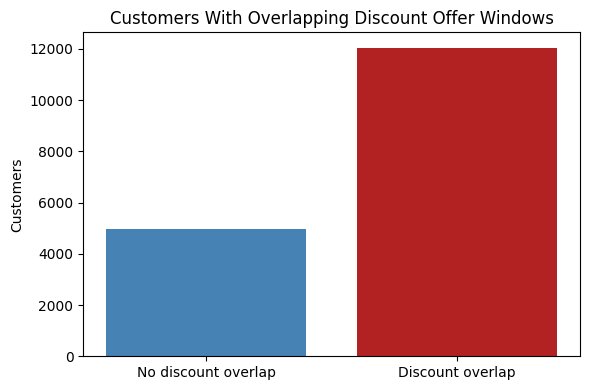

In [33]:
plt.figure(figsize=(6, 4))
plt.bar(["No discount overlap", "Discount overlap"],
        [n_customers_with_offers - n_discount_overlap, n_discount_overlap],
        color=["steelblue", "firebrick"])
plt.title("Customers With Overlapping Discount Offer Windows")
plt.ylabel("Customers")
plt.tight_layout()
plt.savefig("../reports/figures/discount_overlap.png", dpi=150)
plt.show()

**~71% of customers had a discount offer overlapping with another offer.** This is not an edge case — it's the norm, driven by how Starbucks issued offers in waves throughout the study period. This ruled out the simplest fix (excluding overlapping customers), since that would gut ~71% of the sample and bias what remained toward unusually offer-light customers.

**Decision: last-touch attribution.** For any purchase during overlapping windows, credit goes to whichever active offer was most recently *viewed* before the purchase — the industry-standard default for marketing attribution.

**A more important decision, made after further thought:** attribution can't be used to *define treatment* — doing so would condition on post-treatment behavior (viewing), reintroducing selection bias. Treatment is instead defined as **intent-to-treat**: did the customer receive a discount offer at all, regardless of whether they viewed or acted on it. The attribution logic becomes a diagnostic layer, not the treatment definition.

## Step 3: Build the full pipeline

Using the functions in `src/data_prep.py`:
1. Offer windows + viewed events (already built above)
2. Transaction extraction
3. Last-touch attribution (diagnostic layer)
4. Customer-level treatment/outcome table (intent-to-treat)
5. Covariates: age, income, tenure, avg_spend, purchase_frequency, total_transactions

In [34]:
viewed_df = build_viewed_events(transcript_df)
transactions_df = get_transactions(transcript_df)

print(f"Transactions: {transactions_df.shape[0]}")
print(f"Viewed events: {viewed_df.shape[0]}")

Transactions: 138953
Viewed events: 57725


In [35]:
attributed_df = attribute_transactions(transactions_df, windows_df, viewed_df, portfolio_df)

print("Attribution breakdown (diagnostic only — not used as treatment definition):")
display(attributed_df["attributed_offer_type"].value_counts())

Attribution breakdown (diagnostic only — not used as treatment definition):


attributed_offer_type
discount         48535
bogo             46919
unattributed     32860
informational    10639
Name: count, dtype: int64

In [36]:
customer_df = build_customer_level_table(profile_df, windows_df, attributed_df)

print(f"Total customers: {customer_df.shape[0]}")
print("\nTreatment group sizes (intent-to-treat):")
display(customer_df["treatment"].value_counts())

print("\nMean outcome by treatment group:")
display(customer_df.groupby("treatment")["outcome"].mean())

Total customers: 17000

Treatment group sizes (intent-to-treat):


treatment
1    14945
0     2055
Name: count, dtype: int64


Mean outcome by treatment group:


treatment
0     95.426039
1    105.677582
Name: outcome, dtype: float64

In [37]:
customer_df = add_covariates(customer_df, transactions_df)

print(f"Missing demographics (age==118): {customer_df['is_missing_demographics'].sum()}")

clean_df = customer_df[~customer_df["is_missing_demographics"]].copy()

print(f"\nFinal dataset after exclusion: {clean_df.shape[0]} customers")
print("\nCovariate summary:")
display(clean_df[["age", "income", "tenure_days", "avg_spend", "purchase_frequency", "total_transactions"]].describe())

Missing demographics (age==118): 2175

Final dataset after exclusion: 14825 customers

Covariate summary:


,age,income,tenure_days,avg_spend,purchase_frequency,total_transactions
count,14825.000000,14825.000000,14825.000000,14825.000000,14825.000000,14825.000000
mean,54.393524,65404.991568,522.478988,14.909689,0.934123,8.361349
std,17.383705,21598.299410,419.205158,16.511923,1.331800,5.182667
min,18.000000,30000.000000,0.000000,0.000000,0.000000,0.000000
25%,42.000000,49000.000000,208.000000,3.701429,0.305000,4.000000
50%,55.000000,64000.000000,358.000000,13.988333,0.526000,7.000000
75%,66.000000,80000.000000,797.000000,21.298750,0.984000,11.000000
max,101.000000,120000.000000,1823.000000,451.470000,18.000000,36.000000


In [38]:
print("Final treatment group sizes:")
display(clean_df["treatment"].value_counts())

clean_df.to_csv("../data/processed/processed_starbucks.csv", index=False)
print(f"\nSaved {clean_df.shape[0]} customers to data/processed/processed_starbucks.csv")

Final treatment group sizes:


treatment
1    13042
0     1783
Name: count, dtype: int64


Saved 14825 customers to data/processed/processed_starbucks.csv


## Summary

| Step | Finding |
|---|---|
| Portfolio | 4 discount, 4 BOGO, 2 informational offers |
| Profile | 2,175 customers with placeholder/missing demographics, excluded |
| Transcript | Inconsistent key naming (`'offer id'` vs `'offer_id'`) between event types — handled explicitly |
| **Offer overlap** | **~71% of customers had overlapping discount windows — the core challenge of this phase** |
| Treatment definition | Intent-to-treat (received a discount, regardless of viewing/completion) — avoids post-treatment conditioning bias |
| Outcome | Total transaction spend over the full observation period |
| Final dataset | 14,825 customers, 13,042 treated / 1,783 control |